In [1]:
import json
import pandas as pd
from tabulate import tabulate
import os
import re
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Read mapping from results_file_mapping.json
job_ids = [67964195] #['67903336', '67906792']  # List of job IDs to aggregate over
mapping_data = []
for job_id in job_ids:
    results_file_mapping = os.path.join('results_file_mapping', f'{job_id}.json')
    with open(results_file_mapping, 'r') as f:
        mapping_data.extend(json.load(f))


param_to_test = 'n_tokens'
exps_files = {entry['val']: os.path.join('..', '..', entry["path_to_all_results"]) for entry in mapping_data if entry['parameter_name'] == param_to_test}

In [2]:
mean_over_runs = True  # Whether to average over multiple runs with same parameters
separate_classifiers = True

In [14]:
# Aggregate results from all param_to_test experiments
all_results = []

# Get all entries for this parameter (not just unique values)
param_entries = [entry for entry in mapping_data if entry['parameter_name'] == param_to_test]

# Get unique parameter values being tested for this parameter
unique_param_values = set(entry['val'] for entry in param_entries)

jobs_to_exclude = []  # Add any job IDs to exclude here

for entry in param_entries:
    param_val = entry['val']
    file_path = os.path.join('..', '..', entry["path_to_all_results"])
    
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
    except Exception as e:
        print(f"Could not open file related to job_idx={entry.get('job_idx')} for {param_to_test}={param_val}")
        # print(f"Expected file at: {file_path}")
        # print(f"Could not open file for {param_to_test}={param_val} at {os.path.abspath(file_path)}")
        print(f"Error loading {file_path}: {e}")
        continue
    
    if entry.get('job_id') in jobs_to_exclude:
        print(f"Excluding results for {param_to_test}={param_val} (job_id={entry.get('job_id')})")
        continue
    
    for exp_entry in data:
        model = exp_entry['model_name']
        method = exp_entry['method']
        binary_comparisons = exp_entry['binary_comparisons']
        
        for rephrasing in exp_entry['rephrasing_results']:
            classifier = rephrasing['classifier']
            
            all_results.append({
                f'{param_to_test}': param_val,
                'model': model,
                'method': method,
                'rephrasing_method': rephrasing['neighbor_method'],
                'classifier': rephrasing['classifier'],
                'retain_vs_all_auc': rephrasing['Retain vs All AUC'],
                'forget_vs_all_auc': rephrasing['Forget vs All AUC'],
                'holdout_vs_all_auc': rephrasing['Holdout vs All AUC'],
                'multi_class_auc': rephrasing['Multi-class AUC'],
                'accuracy': binary_comparisons['holdout_vs_all'][classifier]['accuracy'],
                'f1': binary_comparisons['holdout_vs_all'][classifier]['f1'],
                'retain_vs_all_auc_at_1_fp': rephrasing['Retain_vs_All_auc_at_1_fp'],
                'forget_vs_all_auc_at_1_fp': rephrasing['Forget_vs_All_auc_at_1_fp'],
                'holdout_vs_all_auc_at_1_fp': rephrasing['Holdout_vs_All_auc_at_1_fp']
            })

# Create DataFrame with all individual results
all_results_raw_df = pd.DataFrame(all_results)

# Average across multiple runs with same parameters
grouping_cols = [f'{param_to_test}', 'model', 'method', 'rephrasing_method', 'classifier']
metric_cols = ['retain_vs_all_auc', 'forget_vs_all_auc', 'holdout_vs_all_auc', 'multi_class_auc',
               'retain_vs_all_auc_at_1_fp', 'forget_vs_all_auc_at_1_fp', 'holdout_vs_all_auc_at_1_fp', 
               'accuracy', 'f1']

if mean_over_runs:
    all_results_df = all_results_raw_df.groupby(grouping_cols, as_index=False)[metric_cols].mean()
else: # median
    all_results_df = all_results_raw_df.groupby(grouping_cols, as_index=False)[metric_cols].median()

# Multiply by 100 for percentage display
for col in metric_cols:
    if col in all_results_df.columns:
        all_results_df[col] = all_results_df[col] * 100
        
# Calculate average number of runs per unique parameter combination
num_runs = int(len(param_entries) / len(unique_param_values)) - len(jobs_to_exclude)

Could not open file related to job_idx=7 for n_tokens=0.6
Error loading ../../comprehensive_results/subset_size-1000/2025_12_27-09_18_05/top_k_18_k_neighbors_15_n_tokens_0.3_MNT_300_test_size_0.2_reph_False_2025_12_27-09_18_05/all_experiment_results.json: [Errno 2] No such file or directory: '../../comprehensive_results/subset_size-1000/2025_12_27-09_18_05/top_k_18_k_neighbors_15_n_tokens_0.3_MNT_300_test_size_0.2_reph_False_2025_12_27-09_18_05/all_experiment_results.json'
Could not open file related to job_idx=8 for n_tokens=0.7
Error loading ../../comprehensive_results/subset_size-1000/2025_12_27-10_47_01/top_k_19_k_neighbors_15_n_tokens_0.3_MNT_300_test_size_0.2_reph_False_2025_12_27-10_47_01/all_experiment_results.json: [Errno 2] No such file or directory: '../../comprehensive_results/subset_size-1000/2025_12_27-10_47_01/top_k_19_k_neighbors_15_n_tokens_0.3_MNT_300_test_size_0.2_reph_False_2025_12_27-10_47_01/all_experiment_results.json'


In [19]:
print("Summary of aggregated results:")
print(f"Total runs loaded: {len(all_results_raw_df)}")
print(f"Results averaged over {num_runs} runs per unique {param_to_test} value.")
print(f"Unique {param_to_test} values tested: {sorted(unique_param_values)}")

Summary of aggregated results:
Total runs loaded: 126
Results averaged over 1 runs per unique n_tokens value.
Unique n_tokens values tested: [0.1, 0.2, 0.3, 0.4, 0.45, 0.5, 0.55, 0.6, 0.7]


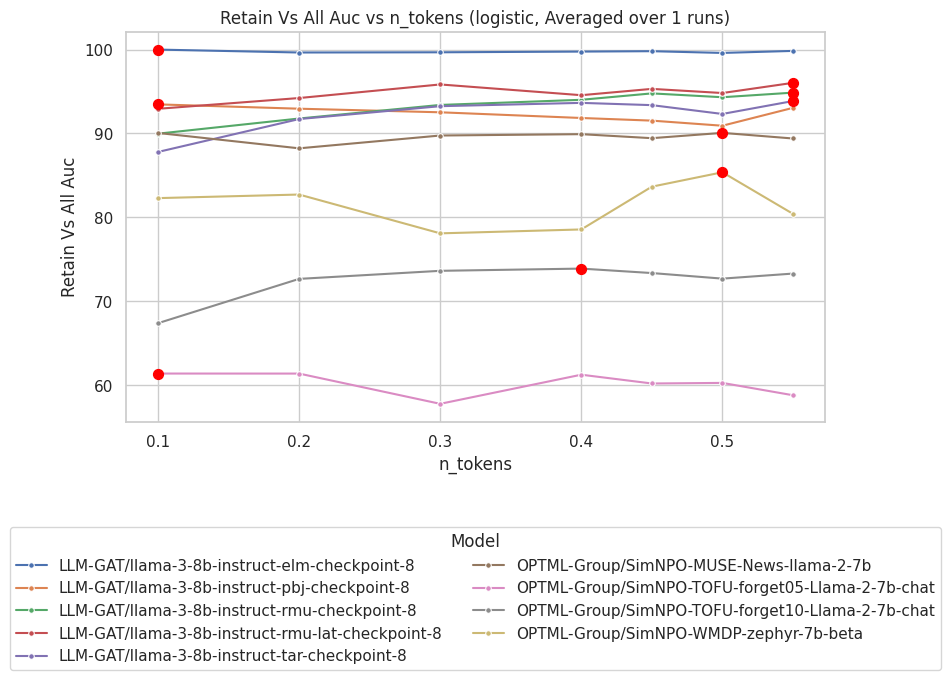

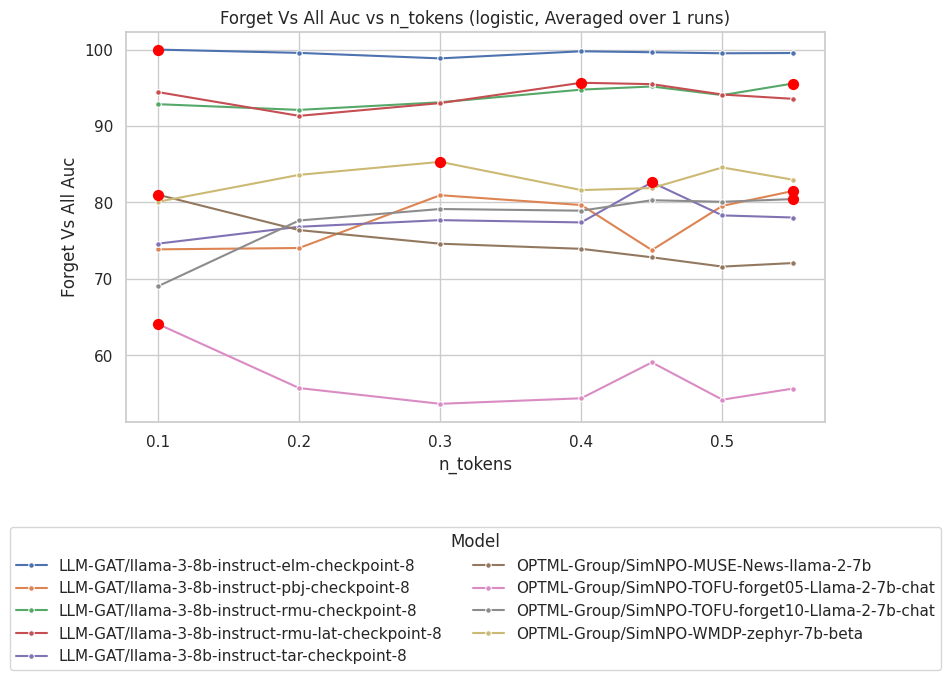

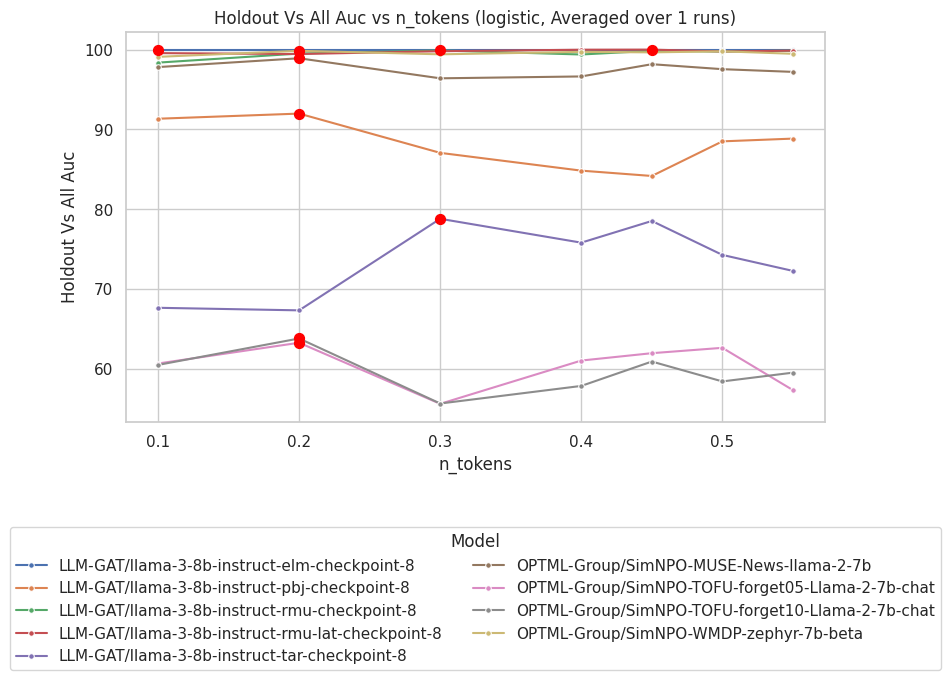

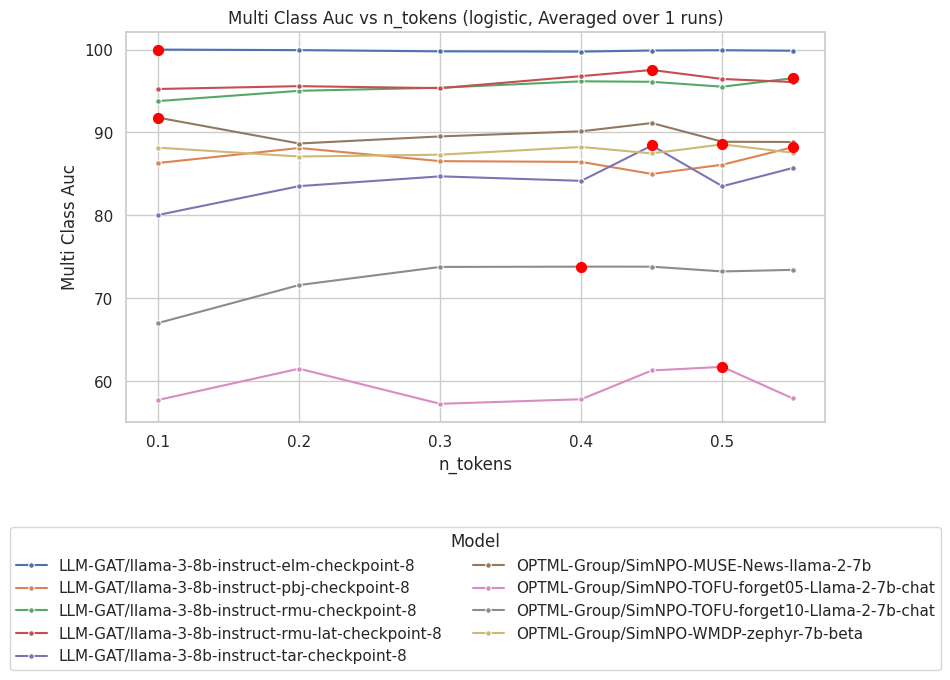

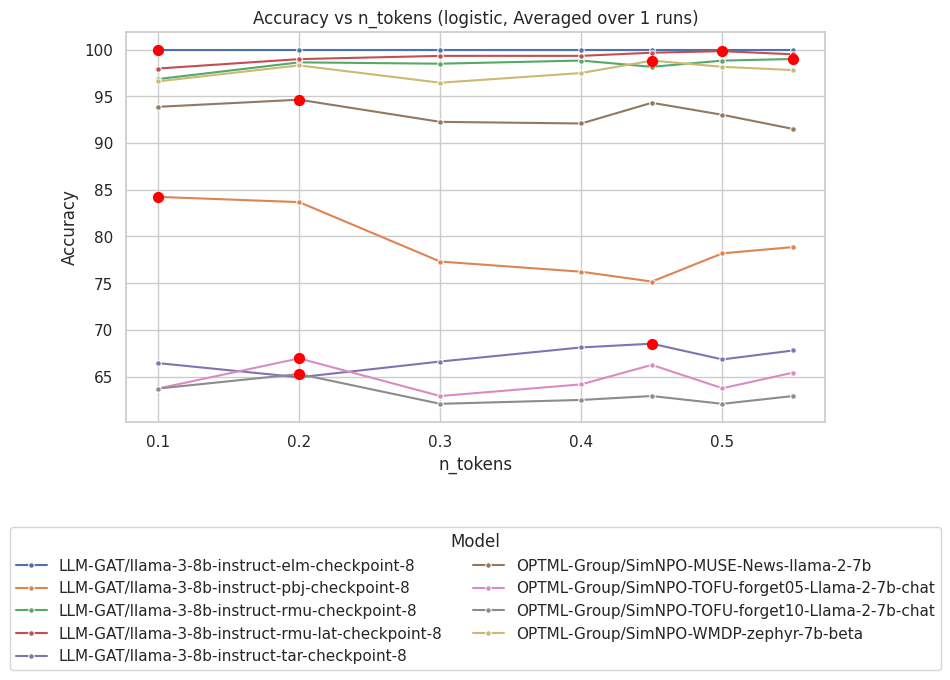

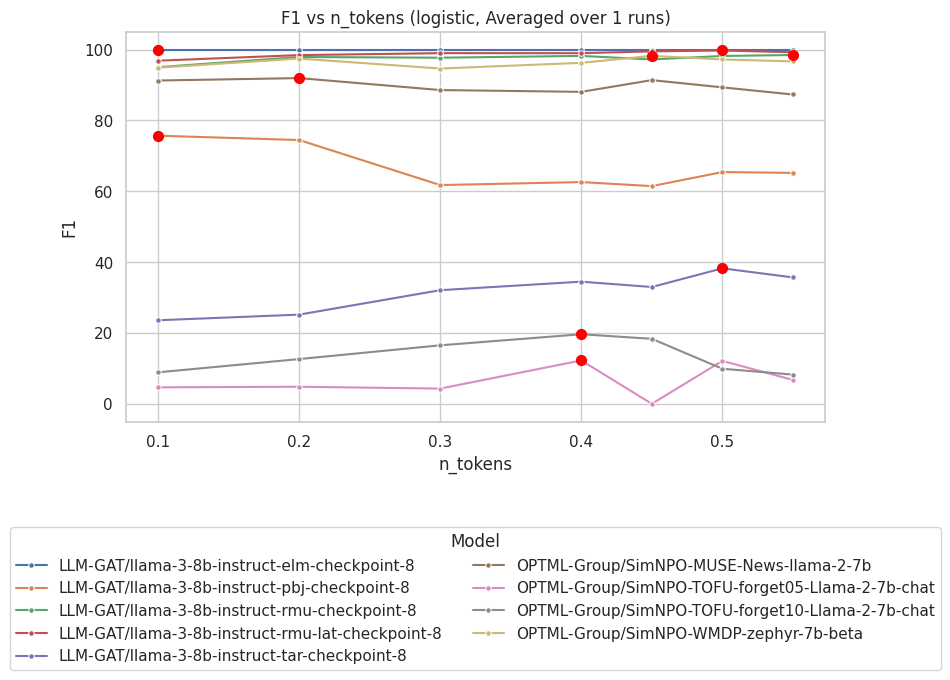

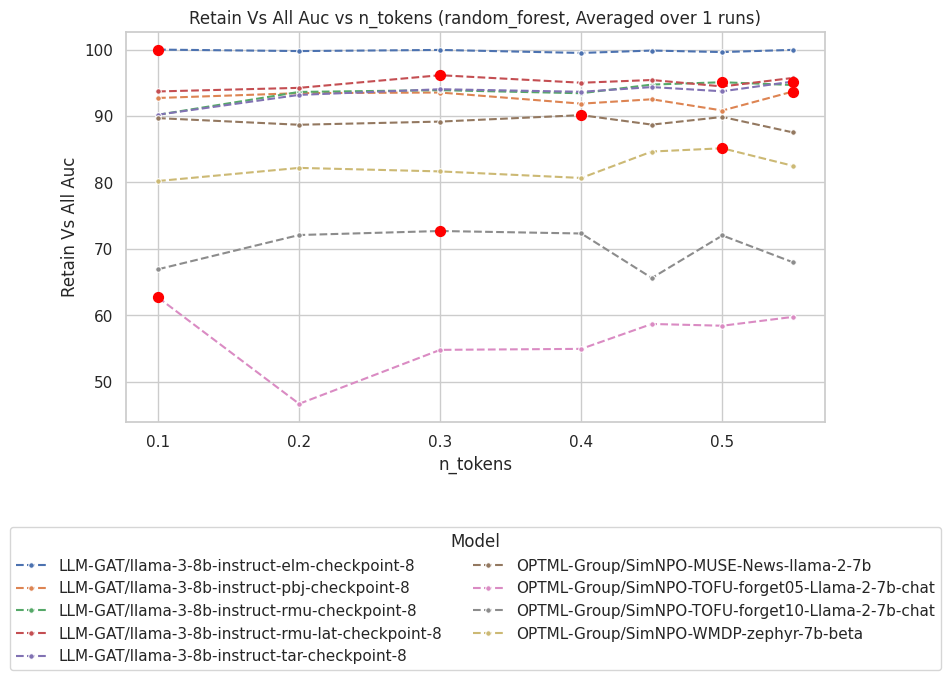

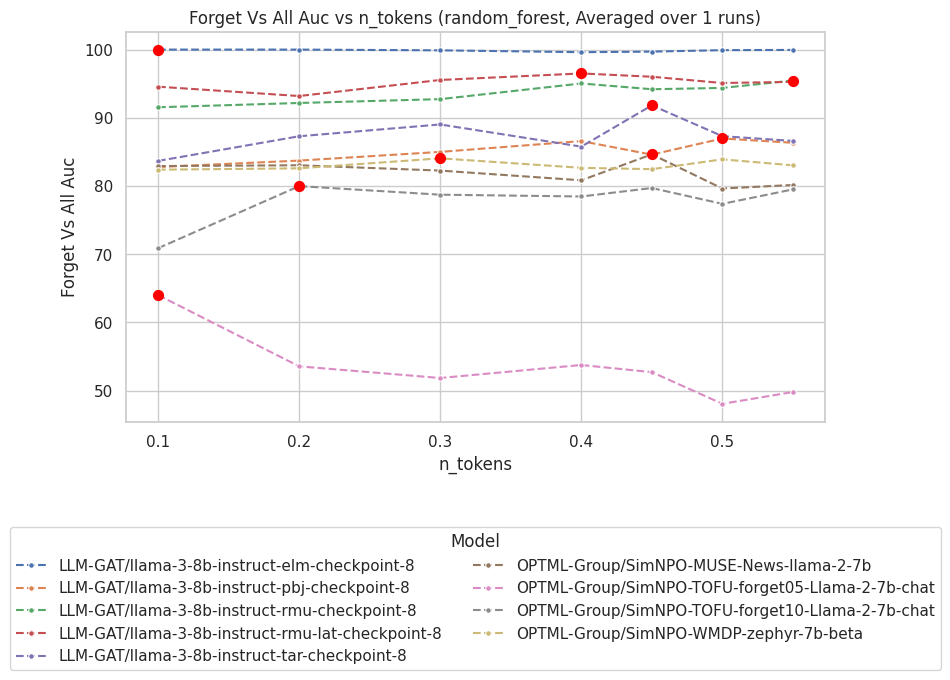

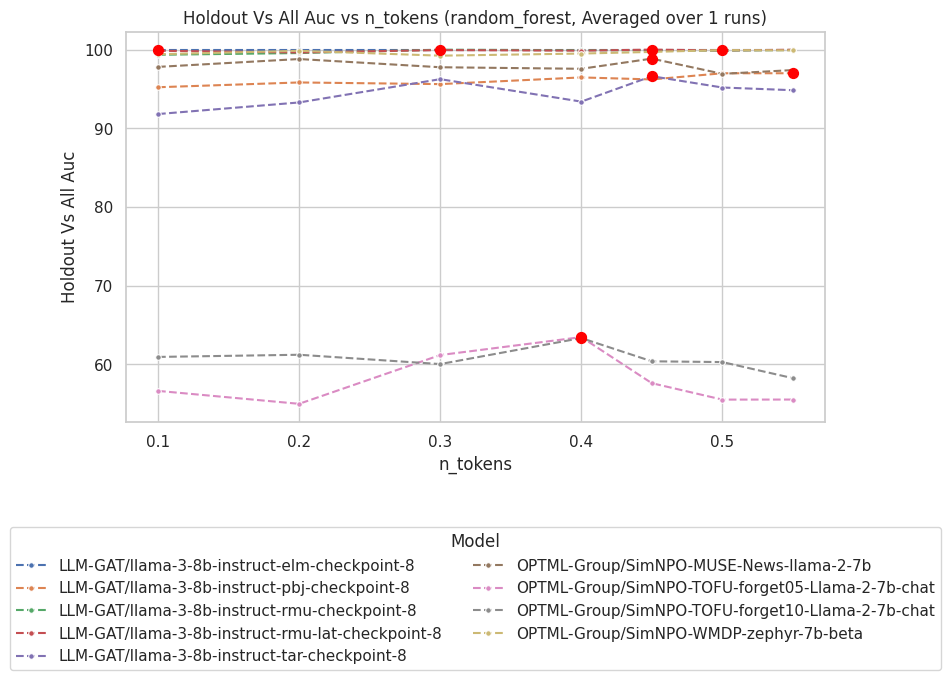

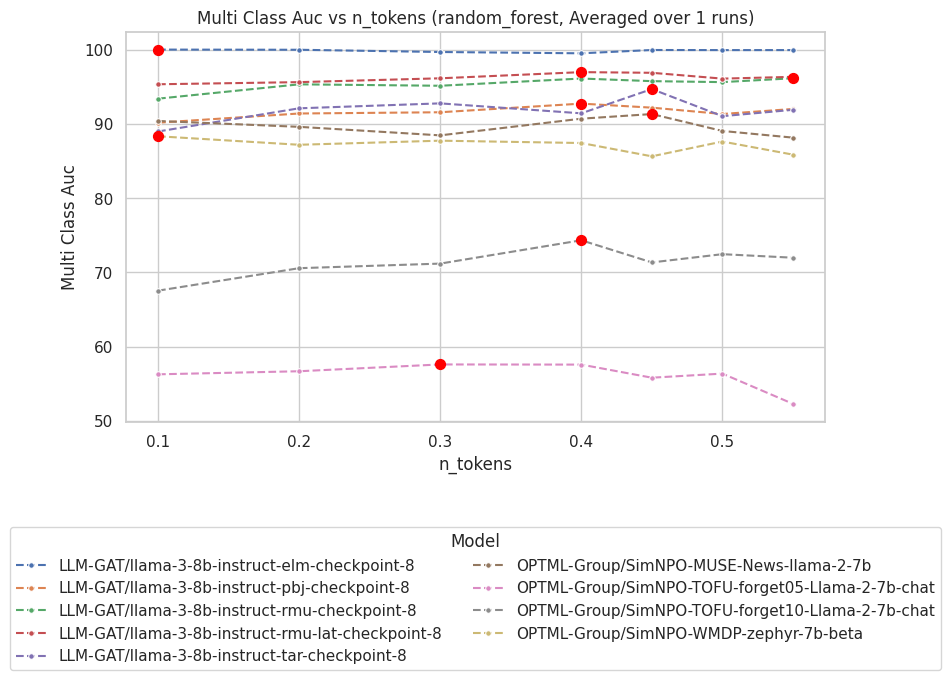

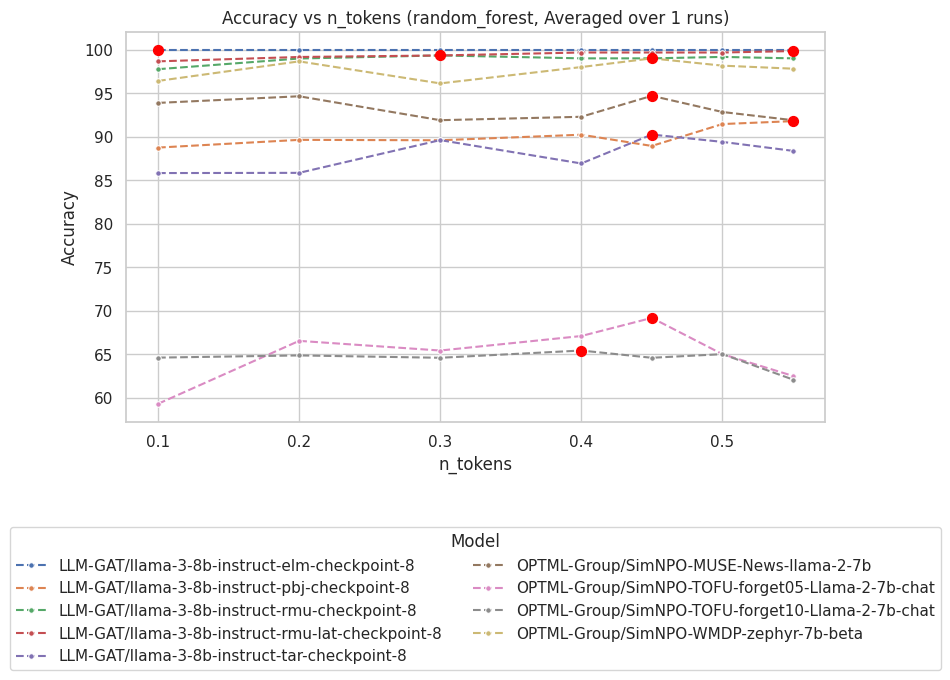

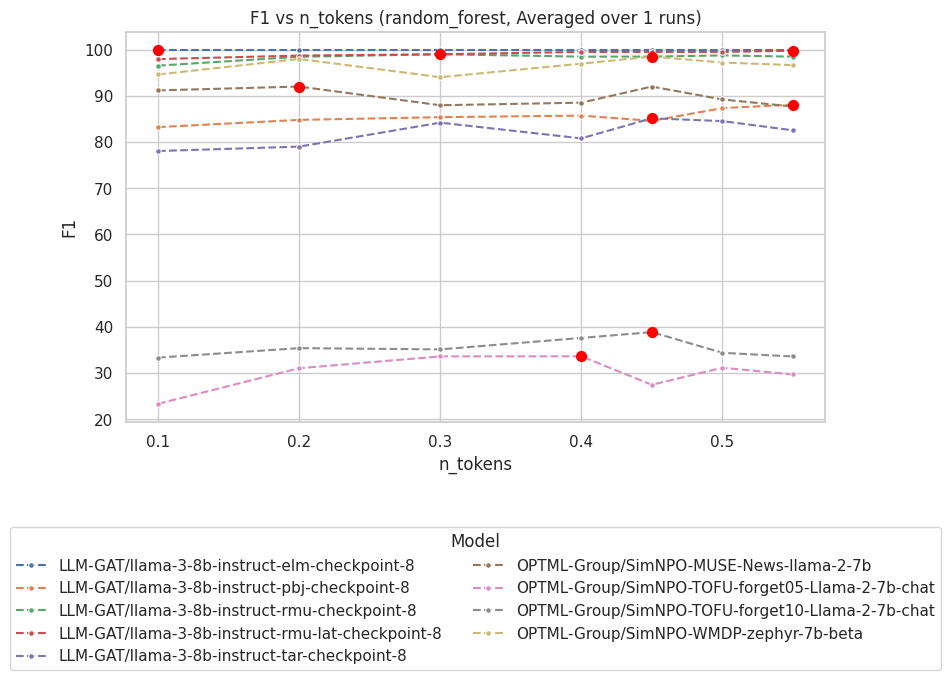

In [ ]:
def plot_metrics_vs_param(all_results_df, param_to_test, metrics_to_plot, classifiers, separate_classifiers=False, num_runs=1):
    sns.set(style='whitegrid')
    if separate_classifiers:
        for classifier in classifiers:
            filtered_df = all_results_df[all_results_df['classifier'] == classifier]
            linestyle = '--' if classifier == 'random_forest' else '-'
            for metric in metrics_to_plot:
                plt.figure(figsize=(8,5))
                sns.lineplot(
                    data=filtered_df,
                    x=f'{param_to_test}',
                    y=metric,
                    hue='model',
                    marker='o',
                    markersize=4,
                    linestyle=linestyle
                )
                for model in filtered_df['model'].unique():
                    model_df = filtered_df[filtered_df['model'] == model]
                    max_idx = model_df[metric].idxmax()
                    max_row = model_df.loc[max_idx]
                    plt.scatter(max_row[f'{param_to_test}'], max_row[metric], color='red', s=50, zorder=5)
                plt.title(f'{metric.replace("_", " ").title()} vs {param_to_test} ({classifier}, Averaged over {num_runs} runs)')
                plt.ylabel(metric.replace('_', ' ').title())
                plt.xlabel(f'{param_to_test}')
                plt.tight_layout()
                plt.legend(title='Model', bbox_to_anchor=(0.5, -0.25), loc='upper center', ncol=2)
                plt.show()
    else:
        for metric in metrics_to_plot:
            plt.figure(figsize=(8,5))
            sns.lineplot(
                data=all_results_df,
                x=f'{param_to_test}',
                y=metric,
                hue='model',
                style='classifier',
                markers=True,
                markersize=4,
            )
            for model in all_results_df['model'].unique():
                for classifier in classifiers:
                    model_class_df = all_results_df[(all_results_df['model'] == model) & (all_results_df['classifier'] == classifier)]
                    if not model_class_df.empty:
                        max_idx = model_class_df[metric].idxmax()
                        max_row = model_class_df.loc[max_idx]
                        plt.scatter(max_row[f'{param_to_test}'], max_row[metric], color='red', s=50, zorder=5)
            plt.title(f'{metric.replace("_", " ").title()} vs {param_to_test} (Combined Classifiers, Averaged over {num_runs} runs)')
            plt.ylabel(metric.replace('_', ' ').title())
            plt.xlabel(f'{param_to_test}')
            plt.tight_layout()
            plt.legend(title='Model / Classifier', bbox_to_anchor=(0.5, -0.25), loc='upper center', ncol=2)
            plt.show()

# Plot with separate classifiers
plot_metrics_vs_param(
    all_results_df=all_results_df,
    param_to_test=param_to_test,
    metrics_to_plot=['retain_vs_all_auc', 'forget_vs_all_auc', 'holdout_vs_all_auc', 'multi_class_auc', 'accuracy', 'f1'],
    classifiers=['logistic', 'random_forest'],
    separate_classifiers=True,
    num_runs=num_runs
)

# Plot combined
# plot_metrics_vs_param(
#     all_results_df=all_results_df,
#     param_to_test=param_to_test,
#     metrics_to_plot=['retain_vs_all_auc', 'forget_vs_all_auc', 'holdout_vs_all_auc', 'multi_class_auc', 'accuracy', 'f1'],
#     classifiers=['logistic', 'random_forest'],
#     separate_classifiers=False
# )

In [20]:
# To check balance: ensure for each param_to_test, each model/method/classifier appears the same number of times
# Group by param_to_test and each column, and print the sizes

for col in ['model', 'method', 'classifier']:
    print(f"\nRuns per ({param_to_test}, {col}):")
    grouped = all_results_raw_df.groupby([f'{param_to_test}', col]).size()
    print(grouped)
    # Check if sizes are equal for each param_to_test
    for val in unique_param_values:
        sub_group = grouped.loc[val]
        unique_sizes = sub_group.unique()
        if len(unique_sizes) > 1:
            print(f"  For {param_to_test}={val}, {col} sizes vary:")
            for k, v in dict(sub_group).items():
                print(f"    {k}: {v}")
        else:
            print(f"  For {param_to_test}={val}, {col} balanced with {unique_sizes[0]} runs each.")
            
# Count entries per {param_to_test} value
from collections import Counter
val_counts = Counter(entry['val'] for entry in param_entries)
print(f"Number of mapping entries per {param_to_test} value:")
for val, count in sorted(val_counts.items()):
    print(f"  {val}: {count}")

# List paths per value
for val in sorted(unique_param_values):
    paths = [entry['path_to_all_results'] for entry in param_entries if entry['val'] == val]
    print(f"For {param_to_test}={val}, paths: {paths}")
    


Runs per (n_tokens, model):
n_tokens  model                                           
0.10      LLM-GAT/llama-3-8b-instruct-elm-checkpoint-8        2
          LLM-GAT/llama-3-8b-instruct-pbj-checkpoint-8        2
          LLM-GAT/llama-3-8b-instruct-rmu-checkpoint-8        2
          LLM-GAT/llama-3-8b-instruct-rmu-lat-checkpoint-8    2
          LLM-GAT/llama-3-8b-instruct-tar-checkpoint-8        2
                                                             ..
0.55      LLM-GAT/llama-3-8b-instruct-tar-checkpoint-8        2
          OPTML-Group/SimNPO-MUSE-News-llama-2-7b             2
          OPTML-Group/SimNPO-TOFU-forget05-Llama-2-7b-chat    2
          OPTML-Group/SimNPO-TOFU-forget10-Llama-2-7b-chat    2
          OPTML-Group/SimNPO-WMDP-zephyr-7b-beta              2
Length: 63, dtype: int64
  For n_tokens=0.1, model balanced with 2 runs each.
  For n_tokens=0.4, model balanced with 2 runs each.
  For n_tokens=0.45, model balanced with 2 runs each.
  For n_tokens=0.3, mod

KeyError: 0.6

In [ ]:
# Use the first file for initial loading
FILE_PATH = list(exps_files.values())[0]

# Load the JSON data
with open(FILE_PATH, 'r') as f:
    data = json.load(f)

# Prepare a list to hold the table rows
table_data = []

for entry in data:
    model = entry['model_name']
    method = entry['method']
    binary_comparisons = entry['binary_comparisons']
    
    for rephrasing in entry['rephrasing_results']:
        rephrasing_method = rephrasing['neighbor_method']
        classifier = rephrasing['classifier']
        
        # Extract AUCs and at_1_fp from rephrasing_results
        retain_auc = rephrasing['Retain vs All AUC']
        forget_auc = rephrasing['Forget vs All AUC']
        holdout_auc = rephrasing['Holdout vs All AUC']
        multi_auc = rephrasing['Multi-class AUC']
        retain_at_1_fp = rephrasing['Retain_vs_All_auc_at_1_fp']
        forget_at_1_fp = rephrasing['Forget_vs_All_auc_at_1_fp']
        holdout_at_1_fp = rephrasing['Holdout_vs_All_auc_at_1_fp']
        
        # Extract Accuracy and F1 from binary_comparisons for holdout_vs_all
        accuracy = binary_comparisons['holdout_vs_all'][classifier]['accuracy']
        f1 = binary_comparisons['holdout_vs_all'][classifier]['f1']
        
        # Append the row
        table_data.append({
            'model': model,
            'method': method,
            'rephrasing_method_(if exists)': rephrasing_method,
            'classifier': classifier,
            'retain_vs_all_auc': retain_auc,
            'forget_vs_all_auc': forget_auc,
            'holdout_vs_all_auc': holdout_auc,
            'multi_class_auc': multi_auc,
            'accuracy': accuracy,
            'f1': f1,
            'retain_vs_all_auc_at_1_fp': retain_at_1_fp,
            'forget_vs_all_auc_at_1_fp': forget_at_1_fp,
            'holdout_vs_all_auc_at_1_fp': holdout_at_1_fp
        })
        
# Create a DataFrame
my_df = pd.DataFrame(table_data)
my_df.index = range(1, len(my_df) + 1)
my_df.index.name = '0'

# Multiply by 100 and round for relevant columns
auc_cols = ['retain_vs_all_auc', 'forget_vs_all_auc', 'holdout_vs_all_auc', 'multi_class_auc', 'retain_vs_all_auc_at_1_fp', 'forget_vs_all_auc_at_1_fp', 'holdout_vs_all_auc_at_1_fp', 'accuracy', 'f1']
for col in auc_cols:
    if col in my_df.columns:
        my_df[col] = (my_df[col] * 100).round(3)

print(tabulate(my_df, headers='keys', tablefmt='tsv', showindex=True))

# Define create_summary_table function
def create_summary_table(df, group_by_column, metrics=['retain_vs_all_auc', 'forget_vs_all_auc', 'holdout_vs_all_auc', 'multi_class_auc', 'retain_vs_all_auc_at_1_fp', 'forget_vs_all_auc_at_1_fp', 'holdout_vs_all_auc_at_1_fp']):
    summary_df = df.groupby(group_by_column).agg({m: 'mean' for m in metrics}).reset_index()
    for col in metrics:
        if summary_df[col].dtype in ['float64', 'int64']:
            summary_df[col] = summary_df[col].round(3)
    summary_df.index = range(1, len(summary_df) + 1)
    summary_df.index.name = '0'
    print(tabulate(summary_df, headers='keys', tablefmt='tsv', showindex=True))
    return summary_df

# Print summaries
create_summary_table(my_df, 'classifier')
print("\n")
create_summary_table(my_df, 'rephrasing_method_(if exists)')
print("\n")
create_summary_table(my_df, ['classifier', 'rephrasing_method_(if exists)'])

  0	model                                           	method  	rephrasing_method_(if exists)  	classifier   	  retain_vs_all_auc	  forget_vs_all_auc	  holdout_vs_all_auc	  multi_class_auc	  accuracy	     f1	  retain_vs_all_auc_at_1_fp	  forget_vs_all_auc_at_1_fp	  holdout_vs_all_auc_at_1_fp
  1	LLM-GAT/llama-3-8b-instruct-elm-checkpoint-8    	ELM     	token_embedding_proximity      	logistic     	             99.676	             98.705	             100    	           99.593	   100    	100    	                     96.985	                     94.472	                     100
  2	LLM-GAT/llama-3-8b-instruct-elm-checkpoint-8    	ELM     	token_embedding_proximity      	random_forest	             99.848	             98.987	             100    	           99.311	   100    	100    	                     97.487	                     96.482	                     100
  3	LLM-GAT/llama-3-8b-instruct-tar-checkpoint-8    	TAR     	token_embedding_proximity      	logistic     	             93.043	       

,classifier,rephrasing_method_(if exists),retain_vs_all_auc,forget_vs_all_auc,holdout_vs_all_auc,multi_class_auc,retain_vs_all_auc_at_1_fp,forget_vs_all_auc_at_1_fp,holdout_vs_all_auc_at_1_fp
0,,,,,,,,,
1,logistic,token_embedding_proximity,86.804,80.878,83.781,85.087,35.03,23.462,45.076
2,random_forest,token_embedding_proximity,85.650,84.318,87.899,86.682,33.69,38.569,50.288


In [ ]:
all_results = []

# Get all entries for this parameter (not just unique values)
param_entries = [entry for entry in mapping_data if entry['parameter_name'] == param_to_test]

# Get unique parameter values being tested for this parameter
unique_param_values = set(entry['val'] for entry in param_entries)

for map_idx, entry in enumerate(param_entries):
    param_val = entry['val']
    file_path = os.path.join('..', '..', entry["path_to_all_results"])

    with open(file_path, 'r') as f:
        data = json.load(f)

    for exp_idx, exp_entry in enumerate(data):
        model = exp_entry['model_name']
        method = exp_entry['method']
        binary_comparisons = exp_entry['binary_comparisons']

        for rephr_idx, rephrasing in enumerate(exp_entry['rephrasing_results']):
            classifier = rephrasing['classifier']

            # add provenance fields so we can track which file/entry produced each row
            all_results.append({
                f'{param_to_test}': param_val,
                'model': model,
                'method': method,
                'rephrasing_method': rephrasing['neighbor_method'],
                'classifier': rephrasing['classifier'],
                'retain_vs_all_auc': rephrasing['Retain vs All AUC'],
                'forget_vs_all_auc': rephrasing['Forget vs All AUC'],
                'holdout_vs_all_auc': rephrasing['Holdout vs All AUC'],
                'multi_class_auc': rephrasing['Multi-class AUC'],
                'accuracy': binary_comparisons['holdout_vs_all'][classifier]['accuracy'],
                'f1': binary_comparisons['holdout_vs_all'][classifier]['f1'],
                'retain_vs_all_auc_at_1_fp': rephrasing['Retain_vs_All_auc_at_1_fp'],
                'forget_vs_all_auc_at_1_fp': rephrasing['Forget_vs_All_auc_at_1_fp'],
                'holdout_vs_all_auc_at_1_fp': rephrasing['Holdout_vs_All_auc_at_1_fp'],
                # provenance
                'source_file': file_path,
                'mapping_idx': map_idx,
                'exp_entry_idx': exp_idx,
                'rephrasing_idx': rephr_idx
            })
# Create DataFrame with all individual results
all_results_raw_df = pd.DataFrame(all_results)

# ...existing code...
# identify outliers at {param_to_test} == 0.5
# identify outliers at {param_to_test} == 0.5
target_val = 0.5
n05_df = all_results_raw_df[all_results_raw_df[param_to_test] == target_val].copy()

if n05_df.empty:
    print(f"No runs with {param_to_test} == {target_val} found.")
else:
    print(f"Total runs at {param_to_test}={target_val}: {len(n05_df)}")

    metric_cols = ['retain_vs_all_auc', 'forget_vs_all_auc', 'holdout_vs_all_auc', 'multi_class_auc',
                   'retain_vs_all_auc_at_1_fp', 'forget_vs_all_auc_at_1_fp', 'holdout_vs_all_auc_at_1_fp',
                   'accuracy', 'f1']

    # compile global thresholds (adjusted multiplier to 2 for less strict detection)
    flagged_ids = set()
    for metric in metric_cols:
        if metric not in n05_df.columns:
            continue
        vals = n05_df[metric].dropna()
        if vals.empty:
            continue
        med = vals.median()
        iqr = vals.quantile(0.75) - vals.quantile(0.25)
        std = vals.std()
        # flag candidates: much below median (use IQR or std, with multiplier 2)
        multiplier = 1.5
        thr_iqr = med - multiplier * iqr  # less strict than 3
        thr_std = vals.mean() - multiplier * std  # fallback
        threshold = thr_iqr if pd.notna(thr_iqr) else thr_std

        # find rows below threshold (significantly low)
        low_mask = n05_df[metric] < threshold
        low_rows = n05_df[low_mask]
        if not low_rows.empty:
            print(f"\nMetric '{metric}': median={med:.4f}, iqr={iqr:.4f}, std={std:.4f}, threshold={threshold:.4f}")
            for idx, row in low_rows.iterrows():
                print(f"  Found low row at DataFrame idx={idx} -> model={row['model']}, method={row['method']}, classifier={row['classifier']}, {metric}={row[metric]:.6f}")
                flagged_ids.add(idx)

    # Additional check: pick minimum rows per metric and show them (with job_idx)
    for metric in metric_cols:
        if metric not in n05_df.columns:
            continue
        min_rows = n05_df.nsmallest(3, metric)
        print(f"\nLowest 3 rows for metric '{metric}' (at {param_to_test}={target_val}):")
        print(min_rows[['model', 'method', 'classifier', metric, 'source_file', 'mapping_idx', 'exp_entry_idx', 'rephrasing_idx']])
        # Extract and print job_idx for these lowest rows
        for idx in min_rows.index:
            row = all_results_raw_df.loc[idx]
            mapping_idx = int(row['mapping_idx'])
            try:
                job_idx = param_entries[mapping_idx].get('job_idx', None)
            except Exception:
                job_idx = None
            print(f"  Lowest row DF idx={idx} -> job_idx: {job_idx}")

    if flagged_ids:
        print("\nPotential outlier run indices (DataFrame index):")
        from collections import Counter
        job_idx_counts = Counter()
        for idx in sorted(flagged_ids):
            row = all_results_raw_df.loc[idx]
            mapping_idx = int(row['mapping_idx'])
            try:
                job_idx = param_entries[mapping_idx].get('job_idx', None)
            except Exception:
                job_idx = None
            if job_idx is not None:
                job_idx_counts[job_idx] += 1
            print(f"- DF idx {idx} -> source_file: {row['source_file']}, mapping_idx: {mapping_idx}, job_idx: {job_idx}, exp_entry_idx: {row['exp_entry_idx']}, rephrasing_idx: {row['rephrasing_idx']}")
        
        if job_idx_counts:
            most_outlier_job_idx = job_idx_counts.most_common(1)[0][0]
            print(f"\nMost outlier job_idx (appears in {job_idx_counts[most_outlier_job_idx]} flagged rows): {most_outlier_job_idx}")
        else:
            print("No job_idx found in flagged rows.")
    else:
        print("No strongly low outliers were detected with current thresholds. You can adjust the IQR/std multiplier to be less strict (e.g., try 1.5).")

Total runs at n_tokens=0.5: 48

Metric 'retain_vs_all_auc': median=0.8944, iqr=0.2036, std=0.1409, threshold=0.5891
  Found low row at DataFrame idx=170 -> model=OPTML-Group/SimNPO-TOFU-forget05-Llama-2-7b-chat, method=SimNPO, classifier=logistic, retain_vs_all_auc=0.558984
  Found low row at DataFrame idx=299 -> model=OPTML-Group/SimNPO-TOFU-forget05-Llama-2-7b-chat, method=SimNPO, classifier=random_forest, retain_vs_all_auc=0.568553
  Found low row at DataFrame idx=426 -> model=OPTML-Group/SimNPO-TOFU-forget05-Llama-2-7b-chat, method=SimNPO, classifier=logistic, retain_vs_all_auc=0.518359
  Found low row at DataFrame idx=427 -> model=OPTML-Group/SimNPO-TOFU-forget05-Llama-2-7b-chat, method=SimNPO, classifier=random_forest, retain_vs_all_auc=0.501875

Metric 'multi_class_auc': median=0.8657, iqr=0.2271, std=0.1398, threshold=0.5251
  Found low row at DataFrame idx=427 -> model=OPTML-Group/SimNPO-TOFU-forget05-Llama-2-7b-chat, method=SimNPO, classifier=random_forest, multi_class_auc=0.